In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Edge Image')

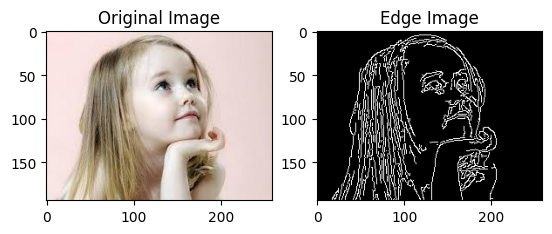

In [8]:
little_girl_img = cv.imread("../../../class.vision/images/little_girl.jpg")

edges = cv.Canny(little_girl_img, 50, 150, apertureSize=3, L2gradient=True)

plt.subplot(121),plt.imshow(little_girl_img[...,::-1]);plt.title('Original Image')
plt.subplot(122),plt.imshow(edges,cmap = 'gray');plt.title('Edge Image')

In [9]:
MAX_VAL = 100
WINDOW_NAME = "Canny Edge Detector"

params_default_state = {
    "threshold": 50,
    "ratio": 150,
    "ap": 3,
    "l2": False,
    "img": None
}

params_state = params_default_state.copy()

def draw_canny_edges(img=None):
    global params_state
    img = params_state.get("img") if img is None else img
    params_state["img"] = img
    if img is None:
        print("No image provided")
        raise ValueError("No image provided")
    t1 = params_state['threshold']
    t2 = params_state['threshold'] * params_state['ratio']
    ap = params_state['ap']
    l2 = params_state['l2']
    print("Canny Params, t1:{}, t2:{}, ap:{}, l2:{}".format(t1, t2, ap, l2))
    edges = cv.Canny(img, t1, t2, apertureSize=ap, L2gradient=l2)
    mask = edges != 0
    dst = img * (mask[:,:,None].astype(img.dtype))
    cv.imshow(WINDOW_NAME, dst)


def ratio_trackbar(val):
    global params_state
    params_state['ratio'] = int(val)
    draw_canny_edges()


def threshold_trackbar(val):
    global params_state
    params_state['threshold'] = int(val)
    draw_canny_edges()


def aperture_trackbar(val):
    global params_state
    map = [3, 5, 7]
    params_state['ap'] = map[int(val)]
    draw_canny_edges()


def l2_trackbar(val):
    global params_state
    params_state['l2'] = bool(int(val))
    draw_canny_edges()

def control_canny_params(img):
    global params_state
    params_state = params_default_state.copy()
    cv.namedWindow(WINDOW_NAME)
    trackbar1 = "Ratio Trackbar"
    cv.createTrackbar(trackbar1, WINDOW_NAME, 0, MAX_VAL, ratio_trackbar)
    trackbar2 = "Threshold Trackbar"
    cv.createTrackbar(trackbar2, WINDOW_NAME, 0, MAX_VAL, threshold_trackbar)
    trackbar3 = "Aperture Trackbar"
    cv.createTrackbar(trackbar3, WINDOW_NAME, 0, 2, aperture_trackbar)
    trackbar4 = "L2?"
    cv.createTrackbar(trackbar4, WINDOW_NAME, 0, 1, l2_trackbar)
    draw_canny_edges(img)
    def wait_till_end(time=None):
        k = cv.waitKey(time) & 0xFF
        if time is None or k == 27:
            cv.destroyAllWindows()
            print("Exit!")
            return True
        return False
    return wait_till_end

In [ ]:
wait_till_end = control_canny_params(little_girl_img)
wait_till_end()

In [ ]:
cap = cv.VideoCapture(0)
initialized = False

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if not initialized:
        wait_till_end = control_canny_params(frame)
        initialized = True
    else:
        draw_canny_edges(frame)

    if wait_till_end(5):
        break

cap.release()